# 逻辑回归-测试代码

> 背景：构建一个逻辑回归模型来预测，某个学生是否被大学录取。
>> 设想一下，你作为一个大学的招生办管理者，你想通过申请学生的两次测试成绩评分，来决定他们是否被录取。现在你所拥有的是之前申请学生的可以用于被训练逻辑回归的训练样本集。对于每一个训练样本，你有他们两次测试的评分和最终是否被录取的结果。为了完成这项任务，我们准备构建一个可以基于两次测试评分来评估录取可能性的分类模型。

## 1. 导包

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. 检查数据

In [43]:
path = "./Datas/examination_admitted_data.csv"
data = pd.read_csv(path)
data.head(10)

,Exam_1,Exam_2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
5,45.083277,56.316372,0
6,61.106665,96.511426,1
7,75.024746,46.554014,1
8,76.098787,87.420570,1
9,84.432820,43.533393,1


In [44]:
# 数据形状
data.shape

(100, 3)

## 3. 可视化原始数据

In [45]:
positive = data[data['Admitted'].isin([1])] # 提取出被录取的样本
negative = data[data['Admitted'].isin([0])] # 提取出未被录取的样本

In [46]:
positive.head()

,Exam_1,Exam_2,Admitted
3,60.182599,86.308552,1
4,79.032736,75.344376,1
6,61.106665,96.511426,1
7,75.024746,46.554014,1
8,76.098787,87.420570,1


In [47]:
negative.head()

,Exam_1,Exam_2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
5,45.083277,56.316372,0
10,95.861555,38.225278,0


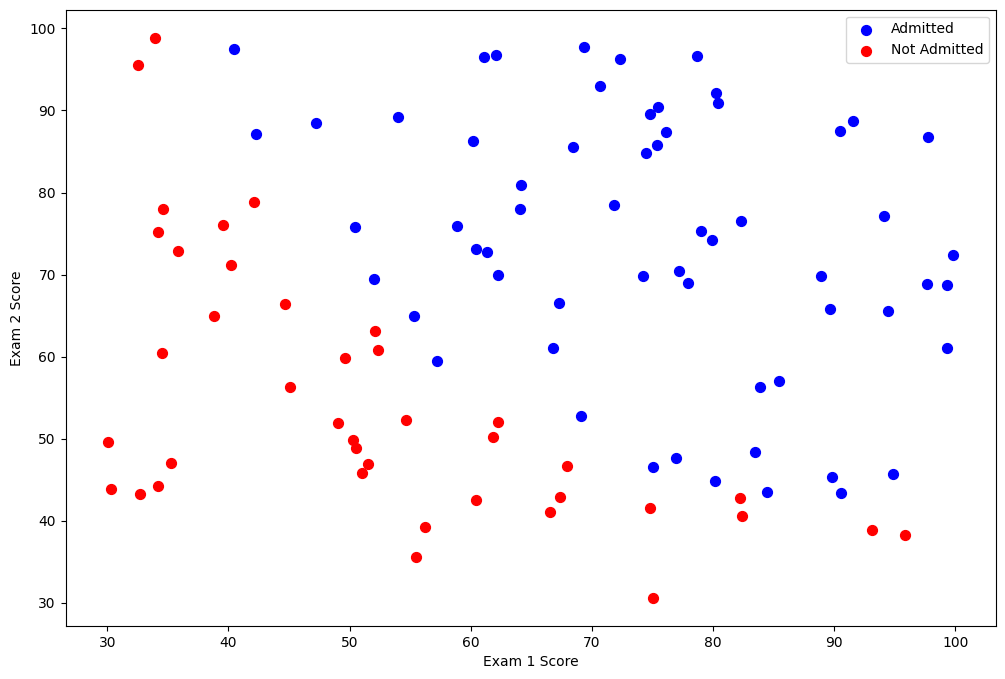

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(positive['Exam_1'],
           positive['Exam_2'],
           s=50,
           c='b',
           label='Admitted'
)
ax.scatter(negative['Exam_1'],
           negative['Exam_2'],
           s=50,
           c='r',
           label='Not Admitted'
)
ax.legend()
ax.set_xlabel('Exam 1 Score')
ax.set_ylabel('Exam 2 Score')
plt.show()

> 从数据可视化来看，被录取的学生和未被录取的学生，这二者之间有一个清晰的决策边界，现在我们可以构建逻辑回归，来训练一个模型进行预测

## 4. Sigmoid函数

g 代编一个常用的逻辑函数（logistic function）为S形状的函数（Sigmoid Function），公式为
$$ g(z) = \frac{1}{1+e^{-z}} $$

逻辑回归模型的假设函数：
$$ h(x) = \frac{1}{1 + e^{-(w^\top x + b)}} $$

In [49]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

> 可视化sigmoid函数，进行快速检查，确保sigmoid函数可以正常工作

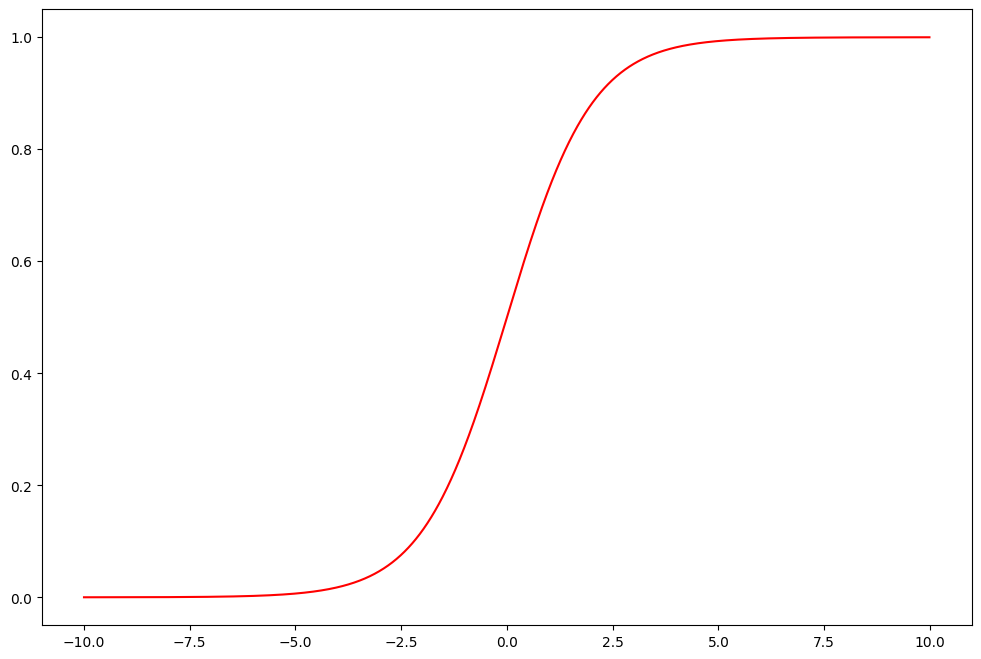

In [50]:
samples = np.arange(-10, 10, 0.01)
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(
    samples,
    sigmoid(samples),
    c='r',
    label='sigmoid'
)
plt.show()

## 5.代价函数

$$ J(w) = -\frac{1}{m}\sum_{i=1}^m(y^{(i)}log(h(x^{(i)})) + (1-y^{(i)})log(1-h(x^{(i)}))) $$

In [51]:
def cost(w, X, y):
    # 将输入特征矩阵 X 转换为 NumPy 数组，确保后续矩阵运算兼容性
    X = np.array(X)
    # 将标签向量 y 转换为 NumPy 数组，并重塑为列向量（n_samples × 1），便于广播运算
    y = np.array(y).reshape(-1, 1)
    # 将权重向量 w 转换为 NumPy 数组，并重塑为列向量（n_features × 1），便于矩阵乘法
    w = np.array(w).reshape(-1, 1)

    # 计算线性组合 X @ w，然后通过 sigmoid 函数得到预测概率，形状为 (n_samples, 1)
    predictions = sigmoid(X @ w)
    # 计算交叉熵损失的第一部分：-y * log(ŷ)，对应正类样本的损失
    first = -y * np.log(predictions)
    # 计算交叉熵损失的第二部分：(1 - y) * log(1 - ŷ)，对应负类样本的损失
    second = (1 - y) * np.log(1 - predictions)
    # 将两部分损失相减后求和，再除以样本数，得到平均损失值
    return np.sum(first - second) / len(X)


## 6. 添加辅助项并检查初始化数据

In [52]:
data.insert(0, "Auxiliary", 1)

cols = data.shape[1]
X = data.iloc[:, 0:cols - 1]
y = data.iloc[:, cols - 1:cols]

X = np.array(X)
y = np.array(y)
w = np.zeros(X.shape[1])

In [53]:
X.shape, y.shape, w.shape

((100, 3), (100, 1), (3,))

## 7.计算初始化代价函数值（w为0）

In [54]:
cost(w, X, y)

0.6931471805599453

## 8.梯度下降 - 批量梯度下降

转化为向量化计算： $ \frac{1}{m}X\top(Sigmoid(XW) - y)$
$$ 
\frac{\partial J}{\partial w_j}=\frac{1}{m}\sum_{i=1}^m(\hat{p}_i - y_i)\,x_{i,j}
$$

In [55]:
def gradient(w, X, y):
    # 将输入的X、y、w统一转换为numpy数组，确保后续矩阵运算的兼容性
    X = np.array(X)                 # 特征矩阵，形状为 (样本数, 特征数)
    y = np.array(y).reshape(-1, 1)  # 将标签列向量化，形状为 (样本数, 1)
    w = np.array(w).reshape(-1, 1)  # 将权重列向量化，形状为 (特征数, 1)

    # 获取参数（特征）数量，即权重的行数
    parameters = w.shape[0]  # 特征维度，决定梯度向量的长度

    # 初始化梯度向量，长度与特征数相同，初始值为0
    grad = np.zeros(parameters)

    # 计算预测值与真实值的误差：sigmoid(X·w) - y
    # X @ w 得到线性组合，sigmoid将其映射到概率空间
    error = sigmoid(X @ w) - y  # 误差向量，形状为 (样本数, 1)

    # 遍历每个特征，计算对应参数的梯度
    for i in range(parameters):
        # 提取第i个特征列，保持列向量形状以便广播乘法
        term = error * X[:, i].reshape(-1, 1)  # 误差与该特征列逐元素相乘
        # 对所有样本的乘积结果求平均，得到该特征的梯度分量
        grad[i] = np.sum(term) / len(X)  # 平均梯度，防止样本数影响梯度大小

    # 返回梯度向量，用于梯度下降更新权重
    return grad

> 注意，我们实际上没有在这个函数中执行梯度下降，我们仅仅在计算一个梯度长。在练习中，一个称为“Fminunc”的Octave函数是用来优化函数来计算成本和梯度参数。由于我们使用Python，我们将使用Scipy的优化函数optimize命名空间来实现梯度下降。

In [56]:
# （1）使用自定义的梯度下降算法
gradient(w, X, y)

array([ -0.1       , -12.00921659, -11.26284221])

In [57]:
# (2) 使用Scipy‘s truncatednewton(TNC) 实现寻找最优参数
import scipy.optimize as opt
results = opt.fmin_tnc(func=cost, x0=w, fprime=gradient, args=(X, y))
results

(array([-25.16131866,   0.20623159,   0.20147149]), 36, 0)

In [58]:
# 接下来看看在使用使用Scipy‘s truncatednewton(TNC) 实现寻找最优参数下的代价函数值
cost(results[0], X, y)

0.2034977015894744

## 9.预测函数

> 使用我们之前用已有的训练集所学习到的参数w来作为数据集X输出预测，然后我们可以使用这个哈桑农户来给我们的分类器的训练精度打分。
> 逻辑回归模型的假设函数：$ h(x) = \frac{1}{1 + e^{-(w^Tx)}} $

- 当 h>=0.5 时，预测为正类
- 当 h<0.5 时，预测为负类

In [59]:
def predict(w, X):
    w = np.array(w).reshape(1, -1)
    X = np.array(X)
    probability = sigmoid(X @ w.T)
    return [1 if x >= 0.5 else 0 for x in probability]

In [61]:
w_min = np.array(results[0])  # 改为 np.array
predictions = predict(w_min, X)
correct = [
    1 if ((a == 1 and b == 1) or (a == 0 and b == 0)) else 0
    for (a, b) in zip(predictions, y)
]
accuracy = (sum(correct) / len(correct)) * 100  # 修复计算错误
print('accuracy = {0}%'.format(accuracy))

accuracy = 89.0%


> 我们的逻辑回归分类器预测正确，如果一个学生被录取或没有录取，达到89%的精确度。不坏！记住，这是训练集的准确性。我们没有保持住了设置或使用交叉验证得到的真实逼近，所以这个数字有可能高于其真实值（这个话题将在以后说明）。